In [ ]:
import pandas as pd
df = pd.read_csv("../data/USGS_Cleaned.csv")
earthquake = df.copy()
earthquake.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-12-09T15:39:11.542Z,30.4765,81.1429,19.232,4.2,mb,26.0,132.0,8.685,0.62,...,2026-01-06T19:24:06.040Z,"20 km N of Burang, China",earthquake,12.04,6.089,0.121,19.0,reviewed,us,us
1,2025-12-07T02:43:07.342Z,29.8698,80.9384,43.404,4.4,mb,21.0,166.0,8.856,0.94,...,2025-12-26T01:20:25.040Z,"37 km E of Dārchulā, Nepal",earthquake,13.18,9.350,0.144,14.0,reviewed,us,us
2,2025-12-04T11:59:01.015Z,29.1109,87.0043,10.000,4.1,mb,36.0,168.0,3.646,1.26,...,2025-12-27T14:38:45.040Z,"130 km N of Lobuche, Nepal",earthquake,10.55,1.930,0.103,26.0,reviewed,us,us
3,2025-11-30T04:57:07.984Z,30.2518,79.4611,25.331,4.3,mb,22.0,177.0,9.893,0.78,...,2025-12-18T05:29:06.040Z,"19 km S of Pīpalkoti, India",earthquake,12.89,6.510,0.138,15.0,reviewed,us,us
4,2025-11-18T04:15:44.332Z,32.4703,84.6414,10.000,4.2,mb,37.0,156.0,6.209,1.23,...,2025-12-11T06:04:42.040Z,western Xizang,earthquake,10.30,1.924,0.110,23.0,reviewed,us,us


In [2]:
# low: 0, moderate: 1, high: 2
def classify_severity(mag):
    if mag < 4.0:
        return 0
    elif mag < 6.0:
        return 1
    else:
        return 2
    
earthquake['severity'] = earthquake['mag'].apply(classify_severity)
earthquake['severity']

0       1
1       1
2       1
3       1
4       1
       ..
2597    1
2598    2
2599    2
2600    2
2601    2
Name: severity, Length: 2602, dtype: int64

In [3]:
earthquake['time'] = pd.to_datetime(earthquake['time'])
earthquake['year'] = earthquake['time'].dt.year
earthquake['month'] = earthquake['time'].dt.month

In [ ]:
eq = earthquake[['latitude', 'longitude', 'depth', 'mag', 'year', 'month', 'severity']]
X = eq.drop(['severity', 'mag'], axis=1)
y = eq[['severity', 'mag']]

,severity,mag
0,1,4.2
1,1,4.4
2,1,4.1
3,1,4.3
4,1,4.2


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
y_test.sample(10)

,severity,mag
1990,1,4.0
2247,1,4.3
1934,1,4.3
1850,1,4.5
316,1,4.0
1658,1,4.7
1195,1,4.3
2395,1,4.7
781,1,4.4
433,1,4.0


In [13]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f'Mean Squared Error: {mean_squared_error(y_test, y_pred)}')
print(f'R2 Score: {r2_score(y_test, y_pred)}')

Mean Squared Error: 0.16096484514409218
R2 Score: 0.23950899753708427


In [19]:
input = pd.DataFrame([[28.28, 84.68, 10.0, 2015, 4]], columns=['latitude', 'longitude', 'depth', 'year', 'month'])
input_scaled = scaler.transform(input)
predicted_severity = model.predict(input_scaled)
severity_mapping = {0: 'Low', 1: 'Moderate', 2: 'High'}
print(f'Predicted severity: {severity_mapping[int(predicted_severity[0][0])]}')
print(f'Earthquake magnitude: {predicted_severity[0][1]}')

Predicted severity: Moderate
Earthquake magnitude: 4.395999999999997


In [17]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
    model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_squared_error'
)
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(by='importance_mean', ascending=True)

feature_importance

,feature,importance_mean,importance_std
0,latitude,0.001114,0.002964
4,month,0.002108,0.001642
1,longitude,0.007798,0.002115
2,depth,0.023210,0.002780
3,year,0.163408,0.008409


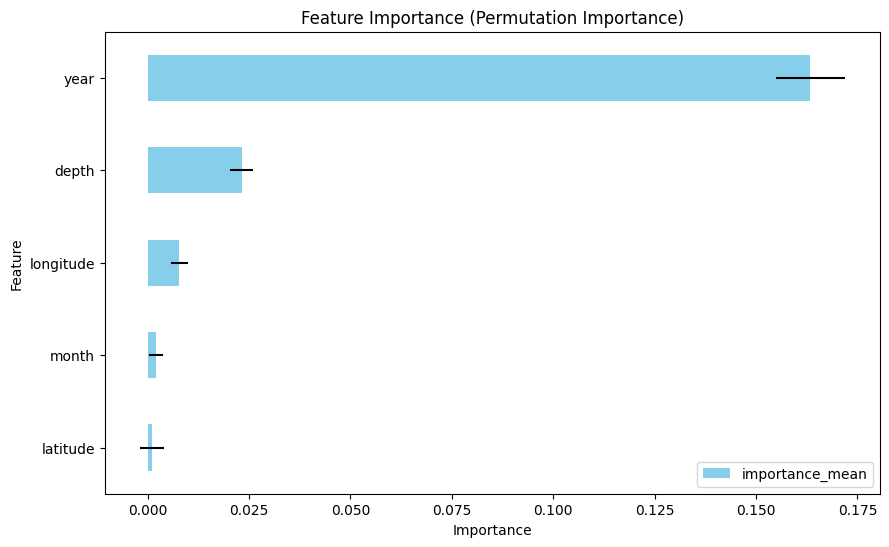

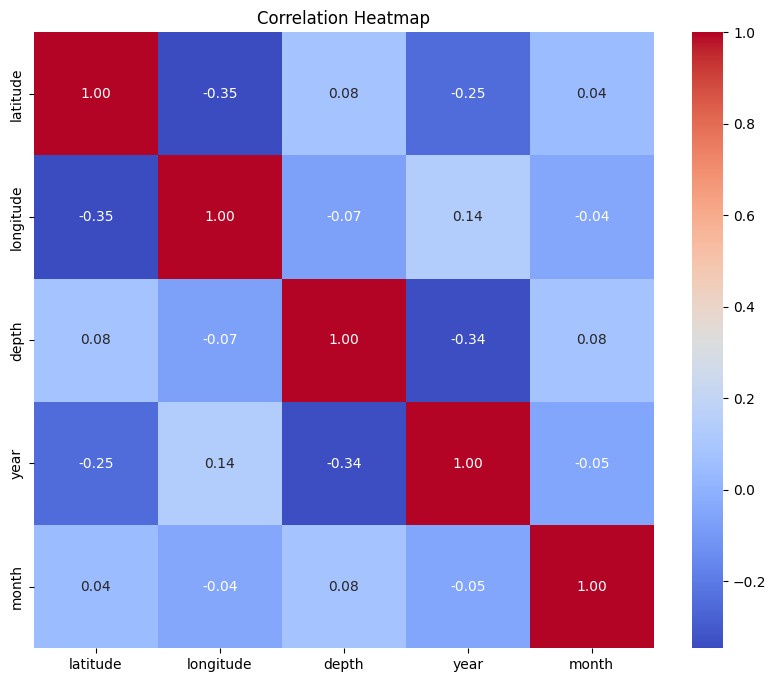

In [18]:
import matplotlib.pyplot as plt
feature_importance.head(15).plot.barh(x='feature', y='importance_mean', xerr='importance_std', legend=True, color='skyblue', figsize=(10, 6))
plt.title('Feature Importance (Permutation Importance)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(X_test.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()